# Steam Review Filter and Score

Capstone Project, Data Science & AI (Institute of Data)

A one-word "good game" or "bad" tells you someone's vote, but not why: no gameplay mechanics, no bugs, no pacing, nothing that helps another player judge whether the game is for them. The original goal has three parts: filter out **low-effort, junk reviews** from text alone so the substantive reviews underneath (the ones that actually explain something) are easier to find; score a game's **real current sentiment** from what's left, since low-effort reviews skew the raw number; and **summarise** that real sentiment in plain English so a player can act on it without reading everything themselves. This notebook builds two compared, evaluated models for the first two parts: a quality filter (Section 5) and a sentiment model (Section 6), plus a summarisation component (Section 7.3) for the third part, using a small fine-tuned summarisation model.

AI assistance disclosure: the pipeline, summarisation component (model selection/testing across seven attempts) and the Streamlit app (UI and deployment) were built with assistance from Claude (Anthropic), used as a coding assistant since I had little experience with generative summarisation models or app deployment. The core data science work in this notebook (EDA, feature engineering, and the model comparisons in Sections 5 and 6) is my own.


## Project Structure (CRISP-DM)

| Phase | Section |
|---|---|
| Business Understanding | Section 1: Problem Framing |
| Data Understanding | Section 2: Data |
| Data Preparation | Section 4: Feature Engineering |
| Exploratory Analysis | Section 3: EDA |
| Modelling | Section 5: Model 1, Section 6: Model 2 |
| Evaluation | Sections 5 and 6 (model comparison), Section 7 (real-world result) |
| Conclusion | Section 8 |

Full business case, stakeholders, and rubric-aligned write-up live in the accompanying project documentation; this notebook stays focused on the analysis itself.

## Pipeline Modules

Reusable logic lives in separate modules, not inline in this notebook, so the same code runs identically here, in the live app, and in any future retrain.

| Module | Purpose |
|---|---|
| `collect_reviews.py` | Pulls reviews from Steam's public API and saves them to CSV |
| `features.py` | English-language filtering and feature engineering (length, playtime, duplicate text, author signals) |
| `train_models.py` | Trains and saves the deployed quality (CNN) and sentiment (Stacking) models |
| `live_scoring.py` | Live-lookup pipeline used by the Streamlit app: pull, clean, score, compare to Steam's vote, summarise |


## Setup

In [1]:
# Standard library
import sys
import glob

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import MultinomialNB

# Scikit-learn: evaluation
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# This project's own pipeline modules (src/); see the module table above
sys.path.append("../src")
from features import (
    drop_non_english_reviews,
    add_length_features,
    add_playtime_features,
    _normalize_text,
)

# Widen pandas' default display so review text isn't truncated when we inspect rows: a lot of our "is this review junk" judgement calls depend on reading the actual text.
pd.set_option("display.max_colwidth", 200)


## Section 1: Problem Framing

**Business problem:** short, thin reviews ("good", "bad", "10/10") sit alongside reviews that actually say something, at roughly equal visibility, so it's harder to find the reviews that actually explain *why* a game is worth (or not worth) your time: gameplay, bugs, story, value.

**Stakeholders:** players deciding whether to buy, who want detail to judge fit, not just a vote count; developers/publishers wanting genuine, substantive feedback; Steam itself.

**Business question:** can we make the useful reviews easy to find and filter out the low-effort/junk ones, using nothing but the review text, then turn what's left into a real sentiment score and a plain-English summary, so a player can see a game's actual current sentiment and act on it without reading everything themselves?

**Data question:** can the model learn from text alone, and does it still work on games it wasn't trained on for (a) sentiment and (b) quality, across genuinely different games and genres?

Full framing and stakeholder detail is in the project documentation.


## Section 2: Data

### 2.1 Collection

Seven games, 20,000 recent English-language reviews each, pulled live from Steam's public `appreviews` API (`src/collect_reviews.py`), chosen to span genuinely different genres:

| Game | Genre | Total English reviews | % sampled |
|---|---|---|---|
| Helldivers 2 | Co-op action shooter | 816,065 | 2.5% |
| Team Fortress 2 | Multiplayer FPS | 739,332 | 2.7% |
| Cyberpunk 2077 | Open-world RPG | 411,481 | 4.9% |
| Resident Evil Requiem | Survival horror / adventure | 79,019 | 25.3% |
| Slay the Spire 2 | Deck-building roguelike | 72,061 | 27.8% |
| Forza Horizon 5 | Racing | 97,866 | 20.4% |
| Tekken 8 | Fighting | 43,200 | 46.3% |

140,000 reviews collected in total, English-only.

I capped every game at 20,000 for three reasons. Balance: keeping every game at the same number means no single game's writing style or slang dominates the dataset. Recency: I pulled the newest reviews first on purpose, since a game can change a lot after launch (patches, balance changes, a monetisation controversy), so a review from last month says more about the game *today* than one from three years ago. Resources: training time and the live app's per-request speed both scale with review count, so the cap keeps things fast to rerun and responsive.

The trade-off with recency: for high-volume games (Helldivers 2, Team Fortress 2, Cyberpunk 2077) this is a thin recent slice (under 5% of their full English review history), not a random sample of the game's whole lifetime, while for lower-volume games like Tekken 8 (46%) it's close to their whole recent history. This matters for Section 3.4's finding that Helldivers 2's recent sample doesn't match its all-time score: a 2.5% slice of very recent reviews is a lot more sensitive to a recent shift than a near-complete history would be.

The same recency-vs-scale trade-off shows up again in Section 8: the goal is eventually a summariser that reads all of a game's reviews, not just a curated sample; it only runs on the ~6 longest kept reviews per game, for the same resource reasons as the 20,000-review cap here.


In [2]:
# Load every CSV in data/raw/ and stack them into one dataframe.
raw_paths = sorted(glob.glob("../data/raw/*.csv"))
df_raw = pd.concat([pd.read_csv(p) for p in raw_paths], ignore_index=True)

df_raw["created_at"] = pd.to_datetime(df_raw["timestamp_created"], unit="s")
df_raw["updated_at"] = pd.to_datetime(df_raw["timestamp_updated"], unit="s")

df_raw.shape


(140000, 24)

### 2.2 A content-based English filter, not just the API tag

Steam's `language=english` parameter is set by the reviewer, not verified against the text: manual inspection found "english"-tagged reviews written in other languages. Since this project needs text I can actually read to check the model's calls, I drop any review with non-Latin script too.


In [3]:
df, dropped_non_english = drop_non_english_reviews(df_raw)

print(f"Dropped {len(dropped_non_english)} of {len(df_raw)} reviews ({len(dropped_non_english)/len(df_raw):.2%}) for containing non-Latin script despite an \"english\" language tag.")
dropped_non_english.groupby("game_name").size().rename("dropped_rows")


Dropped 1490 of 140000 reviews (1.06%) for containing non-Latin script despite an "english" language tag.


game_name
Cyberpunk 2077           115
Forza Horizon 5          260
Helldivers 2              61
Resident Evil Requiem    164
Slay the Spire 2         160
Team Fortress 2          582
Tekken 8                 148
Name: dropped_rows, dtype: int64

## Section 3: Exploratory Data Analysis

### 3.1 How much data do we have, per game?

In [4]:
df.groupby("game_name").size().rename("n_reviews").sort_values(ascending=False)


game_name
Helldivers 2             19939
Cyberpunk 2077           19885
Tekken 8                 19852
Slay the Spire 2         19840
Resident Evil Requiem    19836
Forza Horizon 5          19740
Team Fortress 2          19418
Name: n_reviews, dtype: int64

**Insight:** Each game landed within a few percent of its 20,000-review target after the English-content filter (drop rate 0.3%-2.9% per game).


### 3.1b Checking for missing data

In [ ]:
df.isna().sum().rename("missing_values")


**Insight:** Only one column has missing values: `review` itself, with 483 blank rows out of ~139,000 (about 0.3%); every other column (vote, playtime, timestamps, etc.) is fully populated. Those 483 aren't dropped separately: `fillna("")` in `features.py` turns them into empty strings, which then get caught by Section 4's `is_very_short` check anyway, the same as any other near-empty review.

### 3.2 Review length

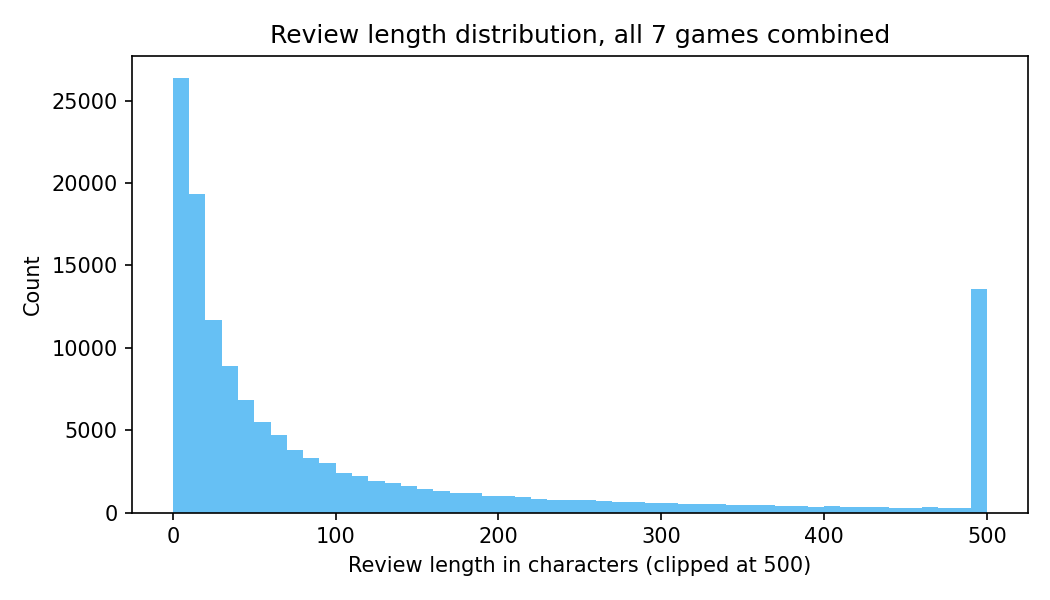

In [1]:
review_len = df["review"].fillna("").str.len()
plt.figure(figsize=(7,4))
plt.hist(review_len.clip(upper=500), bins=50)
plt.xlabel("Review length in characters (clipped at 500)")
plt.ylabel("Count")
plt.title("Review length distribution, all 7 games combined")
plt.show()


**Insight:** There's a real spike right near zero: a lot of reviews are only a handful of characters. This is exactly the kind of review Section 5's quality filter is meant to catch.

### 3.3 Playtime at review

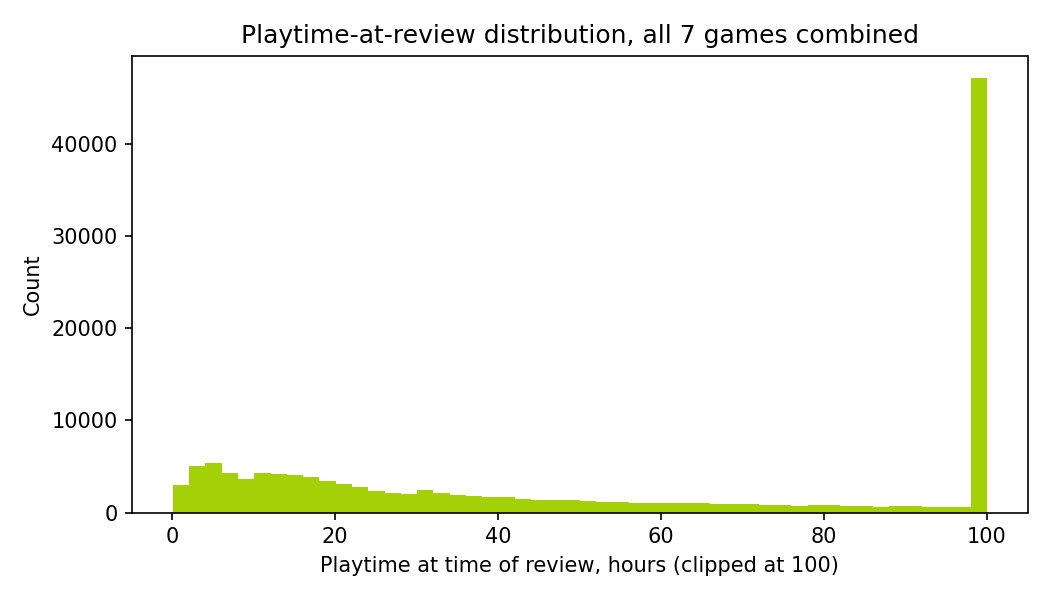

In [1]:
df["playtime_at_review_hours"] = df["playtime_at_review"] / 60
plt.figure(figsize=(7,4))
plt.hist(df["playtime_at_review_hours"].clip(upper=100), bins=50)
plt.xlabel("Playtime at time of review, hours (clipped at 100)")
plt.ylabel("Count")
plt.title("Playtime-at-review distribution, all 7 games combined")
plt.show()


**Insight:** Many reviews come from accounts with under an hour of playtime, which can mean the review isn't based on much hands-on experience with the game.

### 3.4 Sentiment split per game

In [7]:
vote_split = df.groupby("game_name")["voted_up"].value_counts(normalize=True).unstack()
vote_split.columns = ["negative", "positive"]
(vote_split * 100).round(1).sort_values("positive")


,negative,positive
game_name,,
Tekken 8,52.4,47.6
Helldivers 2,48.4,51.6
Slay the Spire 2,22.5,77.5
Forza Horizon 5,11.3,88.7
Team Fortress 2,5.5,94.5
Cyberpunk 2077,4.9,95.1
Resident Evil Requiem,4.4,95.6


**Insight:** Two games sit below 60% positive: Tekken 8 (47.6%, "Mixed" on Steam, real ongoing monetisation backlash) and Helldivers 2 (51.6%). Helldivers 2 is worth noting because its all-time Steam score is "Very Positive" (~80%), and this sample of the most recent 20,000 English reviews is way off that, which shows how a recent-reviews sample can differ from an all-time score. Slay the Spire 2 sits at 77.5% ("Mostly Positive") in this sample; its May 2026 controversy happened after the reviews collected here.


## Section 4: Feature Engineering

### 4.1 Structural features, used to *define* quality, not to *predict* it

| Feature | Why it matters |
|---|---|
| `is_very_short` | Near-zero-effort reviews say little about the game. |
| `is_low_playtime` | A strong opinion after minutes of playtime is a weaker signal than after hours. |
| `is_duplicate_text` | Copy-pasted/templated text is a hallmark of low-effort posting. |

These combine into the *proxy label* (Section 4.2), never fed to the deployed model, which learns from review text alone.

Worth noting why they never go into either model as an extra input either, on top of never building the sentiment label: for the quality filter it genuinely can't: these features literally define its label, so feeding them in as inputs too would just have the model checking its own formula rather than learning anything from the text. The sentiment model is a different case though: its label comes straight from Steam's real vote, not from these features, so adding something like playtime or review length as an extra input there would've been a real option, just one I didn't try, not one ruled out for a specific reason.


In [8]:
df = add_length_features(df)
df = add_playtime_features(df)

# Duplicate-text detection, computed within each game (a duplicate in one
# game's review section says nothing about another game's).
df["_normalized_review"] = df["review"].apply(_normalize_text)
non_empty = df["_normalized_review"] != ""
dup_counts = (
    df[non_empty].groupby(["game_name", "_normalized_review"])["_normalized_review"]
    .transform("count")
)
df["is_duplicate_text"] = False
df.loc[non_empty, "is_duplicate_text"] = dup_counts.gt(1).values
df = df.drop(columns=["_normalized_review"])

df[["is_very_short", "is_low_playtime", "is_duplicate_text"]].mean().round(3)


is_very_short        0.340
is_low_playtime      0.012
is_duplicate_text    0.223
dtype: float64

### 4.2 Defining "low-effort" without a labelled dataset

There's no existing label for "is this review useless," so I built one myself: **low-effort** = very short, OR low playtime, OR duplicate text. It's based on structure, not wording, so training a text model on it isn't circular, and it doesn't depend on any one game's timeline.


In [9]:
df["is_low_effort"] = df["is_very_short"] | df["is_low_playtime"] | df["is_duplicate_text"]

print("Low-effort rate, all games combined:", round(df["is_low_effort"].mean(), 3))
df.groupby("game_name")["is_low_effort"].mean().round(3).sort_values()


Low-effort rate, all games combined: 0.361


game_name
Helldivers 2             0.233
Slay the Spire 2         0.278
Tekken 8                 0.303
Resident Evil Requiem    0.319
Cyberpunk 2077           0.369
Team Fortress 2          0.508
Forza Horizon 5          0.525
Name: is_low_effort, dtype: float64

**Insight:** Low-effort rates range from ~23% (Helldivers 2) to over 50% (Forza Horizon 5, Team Fortress 2). Cyberpunk 2077 sits in the middle (36.9%).


## Section 5: Model 1: Language-Based Review Quality Filter

### 5.1 Splitting before touching anything else

Same leakage-avoidance principle as every model in this project: fit everything (the TF-IDF vocabulary, the model itself) on the training split only.

In [10]:
quality_df = df.copy()
quality_df["label"] = quality_df["is_low_effort"].astype(int)

strat_key = quality_df["game_name"] + "_" + quality_df["label"].astype(str)
q_train, q_test = train_test_split(quality_df, test_size=0.3, random_state=42, stratify=strat_key)

print("train:", q_train.shape, " low-effort rate:", round(q_train["label"].mean(), 3))
print("test: ", q_test.shape, " low-effort rate:", round(q_test["label"].mean(), 3))


train: (96957, 33)  low-effort rate: 0.361
test:  (41553, 33)  low-effort rate: 0.361


### 5.2 Model A: TF-IDF + Logistic Regression

In [11]:
quality_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3)
Xq_train = quality_vectorizer.fit_transform(q_train["review"].fillna(""))
Xq_test = quality_vectorizer.transform(q_test["review"].fillna(""))
yq_train = q_train["label"]
yq_test = q_test["label"]

quality_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
quality_lr.fit(Xq_train, yq_train)

quality_lr_pred = quality_lr.predict(Xq_test)
quality_lr_score = quality_lr.predict_proba(Xq_test)[:, 1]


### 5.3 Model B: TF-IDF + Random Forest

A different algorithm on the same inputs: trees can pick up on patterns between words that a linear model can't.

In [12]:
quality_rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42,
    max_depth=12, min_samples_leaf=5, n_jobs=-1,
)
quality_rf.fit(Xq_train, yq_train)

quality_rf_pred = quality_rf.predict(Xq_test)
quality_rf_score = quality_rf.predict_proba(Xq_test)[:, 1]


### 5.4 Comparing the two models

In [13]:
def evaluate(name, y_true, y_pred, y_score):
    return {
        "model": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }

quality_comparison = pd.DataFrame([
    evaluate("TF-IDF + Logistic Regression", yq_test, quality_lr_pred, quality_lr_score),
    evaluate("TF-IDF + Random Forest", yq_test, quality_rf_pred, quality_rf_score),
])
quality_comparison.round(3)


,model,precision,recall,f1,roc_auc
0,TF-IDF + Logistic Regression,0.826,0.928,0.874,0.962
1,TF-IDF + Random Forest,0.708,0.970,0.819,0.954


### 5.4b Testing more model families

Three more algorithms on the same TF-IDF features: **Linear SVM**, **Multinomial Naive Bayes**, and a **Stacking ensemble** (Logistic Regression + Naive Bayes + Random Forest -> Logistic Regression meta-learner).


In [14]:
# CalibratedClassifierCV wraps the SVM so predict_proba() is available:
# SGDClassifier's raw decision_function scores aren't probabilities, and
# roc_auc_score/our evaluate() helper needs a probability-like score.
quality_svm = CalibratedClassifierCV(
    SGDClassifier(loss="hinge", class_weight="balanced", random_state=42, max_iter=1000), cv=3
)
quality_svm.fit(Xq_train, yq_train)

quality_nb = MultinomialNB()
quality_nb.fit(Xq_train, yq_train)

quality_stack = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        ("nb", MultinomialNB()),
        ("rf", RandomForestClassifier(n_estimators=150, class_weight="balanced", max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, n_jobs=-1,
)
quality_stack.fit(Xq_train, yq_train)

quality_comparison_extended = pd.DataFrame([
    evaluate("TF-IDF + Logistic Regression", yq_test, quality_lr_pred, quality_lr_score),
    evaluate("TF-IDF + Random Forest", yq_test, quality_rf_pred, quality_rf_score),
    evaluate("TF-IDF + Linear SVM", yq_test, quality_svm.predict(Xq_test), quality_svm.predict_proba(Xq_test)[:, 1]),
    evaluate("TF-IDF + Naive Bayes", yq_test, quality_nb.predict(Xq_test), quality_nb.predict_proba(Xq_test)[:, 1]),
    evaluate("Stacking (LogReg + NB + RF -> LogReg)", yq_test, quality_stack.predict(Xq_test), quality_stack.predict_proba(Xq_test)[:, 1]),
])
quality_comparison_extended.round(3)


,model,precision,recall,f1,roc_auc
0,TF-IDF + Logistic Regression,0.826,0.928,0.874,0.962
1,TF-IDF + Random Forest,0.708,0.970,0.819,0.954
2,TF-IDF + Linear SVM,0.845,0.890,0.867,0.956
3,TF-IDF + Naive Bayes,0.790,0.604,0.685,0.911
4,Stacking (LogReg + NB + RF -> LogReg),0.867,0.900,0.883,0.963


**Insight:** Stacking edges out every other classical model (ROC-AUC 0.963, best F1 at 0.883), barely ahead of Logistic Regression (0.962). Naive Bayes trails (0.911) because it assumes every word is independent of the others, which isn't really true for review text.


### 5.4c Model D: CNN (deep learning)

A 1-D CNN reads raw review text directly via a Keras `TextVectorization` layer (vocabulary from the training split only). `Conv1D` + `GlobalMaxPooling1D` are a natural fit for spotting a single short junk phrase anywhere in a review.


In [15]:
VOCAB_SIZE = 8000
SEQ_LEN = 60

train_text = q_train["review"].fillna("").values
test_text = q_test["review"].fillna("").values

tf.random.set_seed(42)
quality_text_vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN)
quality_text_vectorizer.adapt(train_text)

quality_cnn = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    quality_text_vectorizer,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.Conv1D(64, 5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])
quality_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

classes = np.unique(yq_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=yq_train)
quality_cnn_class_weight = dict(zip(classes, weights))
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)

quality_cnn.fit(
    train_text, yq_train.values,
    validation_split=0.1, epochs=10, batch_size=128,
    class_weight=quality_cnn_class_weight, callbacks=[early_stop], verbose=2,
)

quality_cnn_score = quality_cnn.predict(tf.constant(list(test_text), dtype=tf.string), verbose=0).flatten()
quality_cnn_pred = (quality_cnn_score >= 0.5).astype(int)

quality_comparison_final = pd.concat([
    quality_comparison_extended,
    pd.DataFrame([evaluate("CNN (deep learning)", yq_test, quality_cnn_pred, quality_cnn_score)]),
], ignore_index=True)
quality_comparison_final.round(3)


Epoch 1/10
682/682 - 5s - 8ms/step - accuracy: 0.9457 - loss: 0.1837 - val_accuracy: 0.9544 - val_loss: 0.1378
Epoch 2/10
682/682 - 4s - 6ms/step - accuracy: 0.9627 - loss: 0.1235 - val_accuracy: 0.9565 - val_loss: 0.1331
Epoch 3/10
682/682 - 4s - 5ms/step - accuracy: 0.9701 - loss: 0.0986 - val_accuracy: 0.9579 - val_loss: 0.1380


,model,precision,recall,f1,roc_auc
0,TF-IDF + Logistic Regression,0.826,0.928,0.874,0.962
1,TF-IDF + Random Forest,0.708,0.970,0.819,0.954
2,TF-IDF + Linear SVM,0.845,0.890,0.867,0.956
3,TF-IDF + Naive Bayes,0.790,0.604,0.685,0.911
4,Stacking (LogReg + NB + RF -> LogReg),0.867,0.900,0.883,0.963
5,CNN (deep learning),0.932,0.958,0.945,0.987


**Insight:** The CNN beats every classical model (ROC-AUC 0.987 vs. 0.963 for the best one), a big enough gap to be worth the extra complexity.


### 5.5 Does it generalise across games it wasn't specifically tuned for?

In [16]:
q_test_scored = q_test.copy()
q_test_scored["pred"] = quality_lr_pred

per_game = q_test_scored.groupby("game_name").apply(
    lambda g: pd.Series({
        "n": len(g),
        "precision": precision_score(g["label"], g["pred"], zero_division=0),
        "recall": recall_score(g["label"], g["pred"], zero_division=0),
        "actual_rate": g["label"].mean(),
        "predicted_rate": g["pred"].mean(),
    }),
    include_groups=False,
).round(3)
per_game


,n,precision,recall,actual_rate,predicted_rate
game_name,,,,,
Cyberpunk 2077,5966.0,0.833,0.927,0.369,0.410
Forza Horizon 5,5922.0,0.872,0.943,0.525,0.568
Helldivers 2,5982.0,0.772,0.917,0.233,0.276
Resident Evil Requiem,5951.0,0.821,0.927,0.319,0.360
Slay the Spire 2,5952.0,0.810,0.914,0.278,0.314
Team Fortress 2,5825.0,0.843,0.933,0.508,0.562
Tekken 8,5955.0,0.781,0.920,0.303,0.357


**Insight:** Precision (0.77-0.87) and recall (0.91-0.94) are consistent across all seven genres.


### 5.5b Does the CNN's advantage hold up per game too?

The overall ROC-AUC gap in 5.4c could just be the CNN doing really well on one or two games and average on the rest, so I checked precision per game the same way I did for Logistic Regression in 5.5.

In [17]:
q_test_cnn_scored = q_test.copy()
q_test_cnn_scored["pred"] = quality_cnn_pred

cnn_per_game = q_test_cnn_scored.groupby("game_name").apply(
    lambda g: pd.Series({
        "n": len(g),
        "precision": precision_score(g["label"], g["pred"], zero_division=0),
        "recall": recall_score(g["label"], g["pred"], zero_division=0),
    }),
    include_groups=False,
).round(3)
cnn_per_game


,n,precision,recall
game_name,,,
Cyberpunk 2077,5966.0,0.937,0.966
Forza Horizon 5,5922.0,0.956,0.960
Helldivers 2,5982.0,0.911,0.963
Resident Evil Requiem,5951.0,0.934,0.958
Slay the Spire 2,5952.0,0.923,0.953
Team Fortress 2,5825.0,0.932,0.956
Tekken 8,5955.0,0.908,0.951


**Insight:** Precision sits in a tighter, higher band (0.91-0.96) than Logistic Regression's spread (0.77-0.87), including Cyberpunk 2077's RPG-style reviews.

### 5.5c Decision: CNN is the deployed quality-filter model

Since the CNN has a consistent ROC-AUC advantage and precision holds up across all seven genres, it's the one I deployed, saved as one `.keras` file with its vocabulary built in. The trade-off is it's harder to interpret than Logistic Regression, so Section 5.6 uses the classical model just to explain the label, not the CNN's own reasoning.


### 5.5d Example reviews the filter actually caught

Word-importance (5.6 below) shows which *terms* the model leans on, but not what an
actual flagged or kept review looks like. This pulls real reviews straight from the
held-out test set (`q_test_cnn_scored`, same one scored in 5.4c/5.5b), picked by the
CNN's own confidence score, not hand-picked in advance.

In [1]:
examples_df = q_test_cnn_scored.copy()
examples_df["score"] = quality_cnn_score

# Correctly flagged junk, highest confidence, one per game where possible for variety
flagged = examples_df[(examples_df["label"] == 1) & (examples_df["pred"] == 1)].sort_values("score", ascending=False)
# Correctly kept, highest confidence
kept = examples_df[(examples_df["label"] == 0) & (examples_df["pred"] == 0)].sort_values("score", ascending=True)

# One example specifically caught via duplicate copy-pasted text rather than length/playtime,
# to show the filter isn't just "short review = junk"; worth surfacing separately if one exists
# in this particular test split.
dup_only = examples_df[
    (examples_df["label"] == 1) & (examples_df["pred"] == 1) &
    (examples_df["is_duplicate_text"]) & (~examples_df["is_very_short"]) & (~examples_df["is_low_playtime"])
].sort_values("score", ascending=False)


def show_examples(rows, n, heading, confidence_col_is_junk):
    print(f"=== {heading} ===")
    seen_games = set()
    shown = 0
    for _, row in rows.iterrows():
        if row["game_name"] in seen_games:
            continue
        seen_games.add(row["game_name"])
        conf = row["score"] if confidence_col_is_junk else 1 - row["score"]
        print(f"\n[{row['game_name']}] confidence={conf:.3f} | chars={row['review_length_chars']} | "
              f"playtime={row['playtime_at_review_hours']:.2f}h | duplicate_text={row['is_duplicate_text']}")
        print(f'  "{row["review"]}"')
        shown += 1
        if shown >= n:
            break
    print()


show_examples(flagged, 3, "Flagged as low-effort/junk (highest confidence)", confidence_col_is_junk=True)

if len(dup_only):
    print("=== Flagged via duplicate copy-pasted text specifically (not just short/low-playtime) ===")
    row = dup_only.iloc[0]
    print(f"\n[{row['game_name']}] confidence={row['score']:.3f} | chars={row['review_length_chars']} | "
          f"playtime={row['playtime_at_review_hours']:.2f}h")
    print(f'  "{row["review"]}"\n')

show_examples(kept, 3, "Kept as substantive (highest confidence)", confidence_col_is_junk=False)


=== Flagged as low-effort/junk (highest confidence) ===

[Team Fortress 2] confidence=1.000 | chars=2 | playtime=132.63h | duplicate_text=True
  "WW"

[Forza Horizon 5] confidence=1.000 | chars=2 | playtime=19.53h | duplicate_text=True
  "ww"

[Resident Evil Requiem] confidence=1.000 | chars=2 | playtime=27.35h | duplicate_text=False
  "WW"

=== Flagged via duplicate copy-pasted text specifically (not just short/low-playtime) ===

[Helldivers 2] confidence=1.000 | chars=22 | playtime=499.15h
  "GOATED !!!!!!!!!!!!!!!"

=== Kept as substantive (highest confidence) ===

[Resident Evil Requiem] confidence=1.000 | chars=516 | playtime=18.03h | duplicate_text=False
  "Best resident evil I have played since around 2017. It brought back old aspects of the RE games but also new ones too. Leon and graces story are great. Graces horror actually scared me sometimes and i play horror alot. I have played every resident evil game and this is by far top 3. Getting ready to perfect the game now and im

**Insight:** The most confident flagged examples are exactly what you'd expect:
one- or two-character reviews regardless of playtime. The duplicate-text example is the
more interesting case: a review caught purely because its exact wording is copy-pasted
across many other reviews, even from an account with hundreds of hours played. That shows
the filter isn't only catching new or short accounts; it also catches low-effort *text*
from genuinely engaged players.

### 5.6 What words is the model keying on?

In [18]:
terms = quality_vectorizer.get_feature_names_out()
coefs = quality_lr.coef_[0]

top_junk_idx = coefs.argsort()[-15:][::-1]
top_genuine_idx = coefs.argsort()[:15]

quality_word_importance = pd.DataFrame({
    "most_low-effort_terms": terms[top_junk_idx],
    "most_substantive_terms": terms[top_genuine_idx],
})
quality_word_importance


,most_low-effort_terms,most_substantive_terms
0,average,and
1,to hold,with
2,grind,but
3,paint,to
4,spare,after
5,ww,of
6,reality,tho
7,data,wish
8,hold,on
9,can even,game great


**Insight:** Several top "low-effort" terms (`paint`, `spare`, `grind`, `average`) trace back to the same widely copy-pasted review template, the "duplicate text" component of the label doing its job. Top "substantive" terms are ordinary connective words (`and`, `but`, `with`), the kind of words you'd expect from full sentences.


### 5.7 Classification threshold

Both quality-filter predictions above use the model's default 0.5 cutoff, not tuned to a specific precision or recall target. That means flagging something as low-effort and missing something are treated as equally bad, which isn't really true; see documentation Section 8 for more on this, it's listed under future work.

## Section 6: Model 2: Sentiment Scoring

### 6.1 Ground truth: Steam's own thumbs up/down

We use `voted_up` as ground truth. Two approaches: **TF-IDF + Logistic Regression** (classical) and an **LSTM** (deep learning, own word embeddings). Same leakage principle as Section 5: vocabularies fit on the training split only.


### 6.2 Preparing the data

In [19]:
sentiment_df = df[df["review"].fillna("").str.strip() != ""].copy()
sentiment_df["label"] = sentiment_df["voted_up"].astype(int)

print("rows with usable text:", sentiment_df.shape[0], "out of", df.shape[0])
print("positive rate:", round(sentiment_df["label"].mean(), 3))


rows with usable text: 138027 out of 138510
positive rate: 0.785


In [20]:
strat_key_sent = sentiment_df["game_name"] + "_" + sentiment_df["label"].astype(str)
sent_train, sent_test = train_test_split(
    sentiment_df, test_size=0.3, random_state=42, stratify=strat_key_sent
)

print("train:", sent_train.shape, " positive rate:", round(sent_train["label"].mean(), 3))
print("test: ", sent_test.shape, " positive rate:", round(sent_test["label"].mean(), 3))


train: (96618, 33)  positive rate: 0.785
test:  (41409, 33)  positive rate: 0.785


### 6.3 Model A: TF-IDF + Logistic Regression

In [21]:
sent_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3)
Xs_train = sent_vectorizer.fit_transform(sent_train["review"])
Xs_test = sent_vectorizer.transform(sent_test["review"])
ys_train = sent_train["label"]
ys_test = sent_test["label"]

sentiment_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
sentiment_lr.fit(Xs_train, ys_train)

sentiment_lr_pred = sentiment_lr.predict(Xs_test)
sentiment_lr_score = sentiment_lr.predict_proba(Xs_test)[:, 1]


### 6.4 Model B: LSTM (deep learning)

Text -> integer sequences via `TextVectorization` (trained-split vocabulary) -> trainable embedding -> LSTM. `EarlyStopping` halts training once validation loss stops improving.


In [22]:
tf.random.set_seed(42)

VOCAB_SIZE = 8000
SEQ_LEN = 60

text_vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN)
text_vectorizer.adapt(sent_train["review"].values)

lstm_model = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid"),
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

y_sent_train = sent_train["label"].values
y_sent_test = sent_test["label"].values

classes = np.unique(y_sent_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_sent_train)
lstm_class_weight = dict(zip(classes, weights))

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)

lstm_history = lstm_model.fit(
    sent_train["review"].values, y_sent_train,
    validation_split=0.1,
    epochs=10, batch_size=128,
    class_weight=lstm_class_weight,
    callbacks=[early_stop],
    verbose=2,
)

lstm_score = lstm_model.predict(sent_test["review"].values, verbose=0).flatten()
lstm_pred = (lstm_score >= 0.5).astype(int)


Epoch 1/10
680/680 - 21s - 31ms/step - accuracy: 0.8588 - loss: 0.3476 - val_accuracy: 0.8880 - val_loss: 0.2943
Epoch 2/10
680/680 - 14s - 21ms/step - accuracy: 0.9039 - loss: 0.2495 - val_accuracy: 0.8915 - val_loss: 0.2799
Epoch 3/10
680/680 - 14s - 21ms/step - accuracy: 0.9132 - loss: 0.2211 - val_accuracy: 0.8946 - val_loss: 0.2648
Epoch 4/10
680/680 - 14s - 20ms/step - accuracy: 0.9203 - loss: 0.2009 - val_accuracy: 0.8983 - val_loss: 0.2619
Epoch 5/10
680/680 - 14s - 20ms/step - accuracy: 0.9264 - loss: 0.1836 - val_accuracy: 0.8935 - val_loss: 0.2728


### 6.5 Comparing the two models

In [23]:
sentiment_comparison = pd.DataFrame([
    evaluate("TF-IDF + Logistic Regression", ys_test, sentiment_lr_pred, sentiment_lr_score),
    evaluate("LSTM (deep learning)", y_sent_test, lstm_pred, lstm_score),
])
sentiment_comparison.round(3)


,model,precision,recall,f1,roc_auc
0,TF-IDF + Logistic Regression,0.962,0.915,0.938,0.959
1,LSTM (deep learning),0.955,0.920,0.937,0.950


### 6.5b Testing more model families here too

Checking whether Section 5's winners (Stacking, then CNN) also win for sentiment, rather than assuming the result transfers between tasks.


In [24]:
sentiment_stack = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        ("nb", MultinomialNB()),
        ("rf", RandomForestClassifier(n_estimators=150, class_weight="balanced", max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, n_jobs=-1,
)
sentiment_stack.fit(Xs_train, ys_train)
sentiment_stack_pred = sentiment_stack.predict(Xs_test)
sentiment_stack_score = sentiment_stack.predict_proba(Xs_test)[:, 1]


### 6.5c Model D: CNN (deep learning), same architecture as Section 5.4c

Same architecture as the quality filter's CNN, just retrained on the sentiment label, to see if the architecture itself holds up across tasks.


In [25]:
tf.random.set_seed(42)
sentiment_text_vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN)
sentiment_text_vectorizer.adapt(sent_train["review"].fillna("").values)

sentiment_cnn = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    sentiment_text_vectorizer,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.Conv1D(64, 5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])
sentiment_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

sentiment_cnn.fit(
    sent_train["review"].fillna("").values, y_sent_train,
    validation_split=0.1, epochs=10, batch_size=128,
    class_weight=lstm_class_weight, callbacks=[early_stop], verbose=2,
)

sentiment_cnn_score = sentiment_cnn.predict(
    tf.constant(list(sent_test["review"].fillna("").values), dtype=tf.string), verbose=0
).flatten()
sentiment_cnn_pred = (sentiment_cnn_score >= 0.5).astype(int)

sentiment_comparison_final = pd.concat([
    sentiment_comparison,
    pd.DataFrame([
        evaluate("Stacking (LogReg + NB + RF -> LogReg)", ys_test, sentiment_stack_pred, sentiment_stack_score),
        evaluate("CNN (deep learning)", y_sent_test, sentiment_cnn_pred, sentiment_cnn_score),
    ]),
], ignore_index=True)
sentiment_comparison_final.round(3)


Epoch 1/10
680/680 - 5s - 7ms/step - accuracy: 0.8459 - loss: 0.3573 - val_accuracy: 0.8944 - val_loss: 0.2632
Epoch 2/10
680/680 - 4s - 6ms/step - accuracy: 0.9088 - loss: 0.2365 - val_accuracy: 0.8973 - val_loss: 0.2566
Epoch 3/10
680/680 - 4s - 5ms/step - accuracy: 0.9338 - loss: 0.1834 - val_accuracy: 0.8972 - val_loss: 0.2722


,model,precision,recall,f1,roc_auc
0,TF-IDF + Logistic Regression,0.962,0.915,0.938,0.959
1,LSTM (deep learning),0.955,0.920,0.937,0.950
2,Stacking (LogReg + NB + RF -> LogReg),0.943,0.955,0.949,0.959
3,CNN (deep learning),0.962,0.912,0.936,0.957


**Insight:** Stacking leads on F1 (0.949 vs. Logistic Regression's 0.938) and recall (0.955 vs. 0.915), and agrees with Steam's real vote most often (91.8% vs. 90.4%), but it ties Logistic Regression exactly on ROC-AUC (0.959 both), reporting that straight rather than only picking the metric that favours Stacking. The CNN (0.957) and LSTM (0.950) come in a bit behind.

Unlike the quality filter, deep learning doesn't clearly win here, which is worth knowing on its own.

**Decision:** the live app deploys **Stacking (Logistic Regression + Naive Bayes + Random Forest)**. It wins on F1, recall, and agreement with the real vote, and it's fast enough (~65ms for a 1,000-review batch) that it barely matters next to the multi-second Steam API call already happening in the pipeline.


Classical ML and deep learning land close together on the base LR-vs-LSTM comparison. Section 6.5b-c below extends this with two more model families and explains which model is deployed.


### 6.6 What words is the model keying on?

Using the classical Logistic Regression component to explain the signal (the deployed Stacking ensemble isn't directly interpretable). Top positive terms are generic praise (`best`, `amazing`, `masterpiece`). Top negative terms include real, specific names: `arrowhead` (Helldivers 2's developer), `season` (battle-pass language), `anita` (Slay the Spire 2's controversy), lining up with the negativity spikes in Section 3.4.


In [26]:
feature_names = sent_vectorizer.get_feature_names_out()
top_positive_idx = sentiment_lr.coef_[0].argsort()[-15:][::-1]
top_negative_idx = sentiment_lr.coef_[0].argsort()[:15]

sentiment_word_importance = pd.DataFrame({
    "most_positive_terms": feature_names[top_positive_idx],
    "most_negative_terms": feature_names[top_negative_idx],
})
sentiment_word_importance


,most_positive_terms,most_negative_terms
0,best,devs
1,10 10,arrowhead
2,amazing,anita
3,masterpiece,season
4,perfect,worst
5,not bad,refund
6,great,developers
7,peak,not worth
8,good,ruined
9,better than,worse


### 6.7 Classification threshold

Same as Section 5.7: the sentiment model also uses the default 0.5 cutoff, not tuned. See documentation Section 8 for detail.

## Section 7: Putting It Together: A Real Sentiment Score

### 7.1 Before vs. after filtering low-effort reviews

Apply the Section 5 quality filter to every review, then compare each game's raw `voted_up` percentage against the percentage using only reviews not flagged as low-effort.


In [27]:
def to_steam_category(pct_positive):
    if pct_positive >= 95: return "Overwhelmingly Positive"
    if pct_positive >= 80: return "Very Positive"
    if pct_positive >= 70: return "Mostly Positive"
    if pct_positive >= 40: return "Mixed"
    if pct_positive >= 20: return "Mostly Negative"
    return "Overwhelmingly Negative"

# Score every review in the full dataset with the Section 5 quality model
# (fit on q_train only; df itself was never used to fit quality_vectorizer/quality_lr).
Xq_full = quality_vectorizer.transform(df["review"].fillna(""))
df["quality_pred"] = quality_lr.predict(Xq_full)  # 1 = flagged as low-effort

before_after = df.groupby("game_name").apply(
    lambda g: pd.Series({
        "n_reviews": len(g),
        "pct_flagged_low_effort": (g["quality_pred"] == 1).mean() * 100,
        "pct_positive_before": g["voted_up"].mean() * 100,
        "pct_positive_after": g.loc[g["quality_pred"] == 0, "voted_up"].mean() * 100,
    }),
    include_groups=False,
).round(1)
before_after["category_before"] = before_after["pct_positive_before"].apply(to_steam_category)
before_after["category_after"] = before_after["pct_positive_after"].apply(to_steam_category)
before_after.sort_values("pct_positive_before", ascending=False)


,n_reviews,pct_flagged_low_effort,pct_positive_before,pct_positive_after,category_before,category_after
game_name,,,,,,
Resident Evil Requiem,19836.0,36.2,95.6,93.9,Overwhelmingly Positive,Very Positive
Cyberpunk 2077,19885.0,41.5,95.1,92.9,Overwhelmingly Positive,Very Positive
Team Fortress 2,19418.0,56.5,94.5,92.1,Very Positive,Very Positive
Forza Horizon 5,19740.0,57.2,88.7,78.6,Very Positive,Mostly Positive
Slay the Spire 2,19840.0,31.7,77.5,74.9,Mostly Positive,Mostly Positive
Helldivers 2,19939.0,27.9,51.6,39.9,Mixed,Mostly Negative
Tekken 8,19852.0,35.4,47.6,37.9,Mixed,Mostly Negative


**Observations:**

- Filtering low-effort reviews *lowers* the positive percentage for all seven games: low-effort reviews skew more positive than substantive ones.
- Tekken 8 and Forza Horizon 5 each cross a full Steam category (Mixed -> Mostly Negative; Very Positive -> Mostly Positive).
- Helldivers 2 moves the most in raw points (51.6% -> 39.9%) but stays "Mixed"; it has the lowest low-effort rate in the dataset (23.3%).


### 7.2 Validating the sentiment model against Steam's real vote

How often does the deployed sentiment model's text-only prediction agree with the reviewer's real vote? Uses `sentiment_stack`, the model actually deployed.


In [28]:
Xs_full = sent_vectorizer.transform(sentiment_df["review"])
sentiment_df["predicted_sentiment"] = sentiment_stack.predict(Xs_full)

agreement = (
    (sentiment_df["predicted_sentiment"] == sentiment_df["label"])
    .groupby(sentiment_df["game_name"]).mean() * 100
).round(1).rename("agreement_pct").sort_values(ascending=False)
agreement


game_name
Resident Evil Requiem    96.4
Cyberpunk 2077           95.8
Forza Horizon 5          94.7
Team Fortress 2          94.4
Slay the Spire 2         92.4
Helldivers 2             89.8
Tekken 8                 83.2
Name: agreement_pct, dtype: float64

**Insight:** Agreement ranges from 83-96% across games. Tekken 8 is the lowest (83.2%), probably because a lot of the monetisation-driven reviews praise the gameplay in the text but still vote the game down, which is the kind of mismatch that's hard for a text-only model to catch.


### 7.3 Plain-English summaries, the third part of the goal

Filtering and scoring tell you *what* a game's real sentiment is; this part tries to explain *why*, in a form a player can actually read. There's no precision/recall/ROC-AUC for a generated summary the way there is for Sections 5 and 6, so this is more of a build log than a metrics comparison. The deployed app generates a "Players liked: ..." / "Players disliked: ..." summary from the kept reviews, using Falconsai/text_summarization, a t5-small checkpoint fine-tuned for summarisation. I tried six summariser models in total: five pretrained generative ones (t5-small, bart-large-cnn, distilbart-cnn-12-6, flan-t5-base, flan-t5-small) got rejected either for incoherent/hallucinated output or for using too much memory for the free-tier host, and an extractive TF-IDF approach was tried briefly after that; it couldn't hallucinate, but it also couldn't produce real prose. Falconsai/text_summarization has the same memory footprint as t5-small but is actually fine-tuned for summarising, so I went with that. Each kept review gets summarised on its own and the short results get joined together, which fixed an earlier problem where summarising several reviews in one go would quietly drop one of them. Full detail is in the README and project documentation.


## Section 8: Conclusion & Future Work

Full business framing and discussion is in the project documentation; this section is intentionally brief.

### Findings

- A model trained on review text alone can filter low-effort reviews and predict sentiment consistently across seven very different genres. **Quality filter (deployed): CNN**, ROC-AUC 0.987. **Sentiment (deployed): Stacking**, F1 0.949, 83-96% agreement with Steam's real vote.
- Filtering out low-effort reviews consistently *lowers* a game's score instead of cleaning it up, true for all seven games.
- All three parts of the original goal are working and deployed: filter, score, and a plain-English summary of the real sentiment (Section 7.3). The summary only runs on a curated ~6-review sample per game, not the full pull; that gap is covered under Future work below.

### Limitations

- The "low-effort" label is a proxy, not verified ground truth.
- The duplicate-text check only catches *exact* matches (after lowercasing/punctuation removal) within the same game; a reworded copy-paste, or the same phrase reused across different games, won't be flagged.
- Scoped to English-language reviews only.
- This is a sample of the most recent reviews, not full history, so it can diverge from a game's all-time Steam score (Section 3.4).

Full limitations discussion is in the project documentation.

### Future work

- Validate against a broader genre spread and calibrate the flagging threshold against a real precision/recall target.
- Build this into an actual website where you can search any game from Steam's library and get a few-sentence summary of what all its reviews are saying, not just the curated ~6-review sample shown in the app.
- Swap in a better summariser model. Falconsai is small and mostly stitches review fragments together rather than writing genuinely new sentences; a bigger transformer or an LLM would do a better job. Testing Qwen through Ollama locally could write real, new sentences instead of just joining quotes together, a clear step up from what's deployed.
- Get better at catching sarcasm and mixed-signal reviews, where someone says good and bad things in the same review or means the opposite of what they're typing; both the sentiment model and the summariser can miss this. Full detail on all of this in the project documentation.
